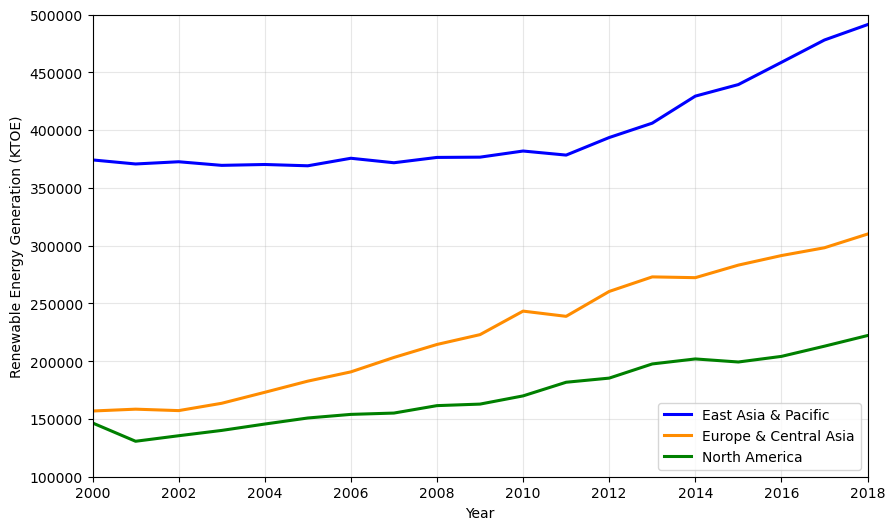

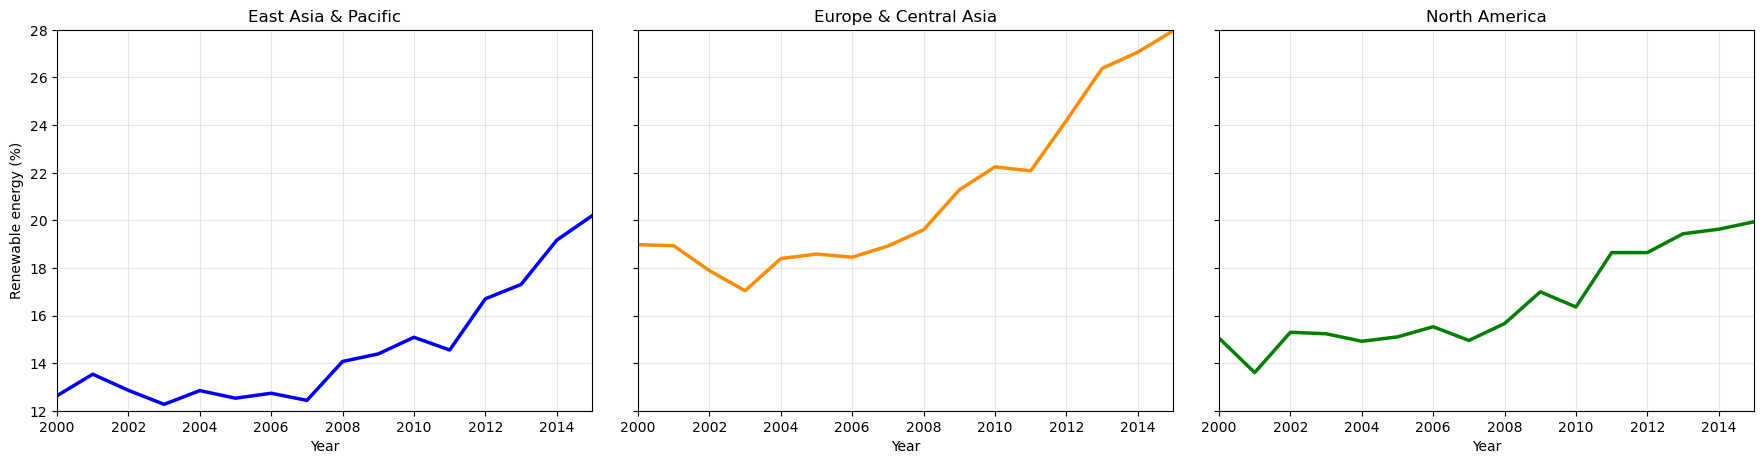

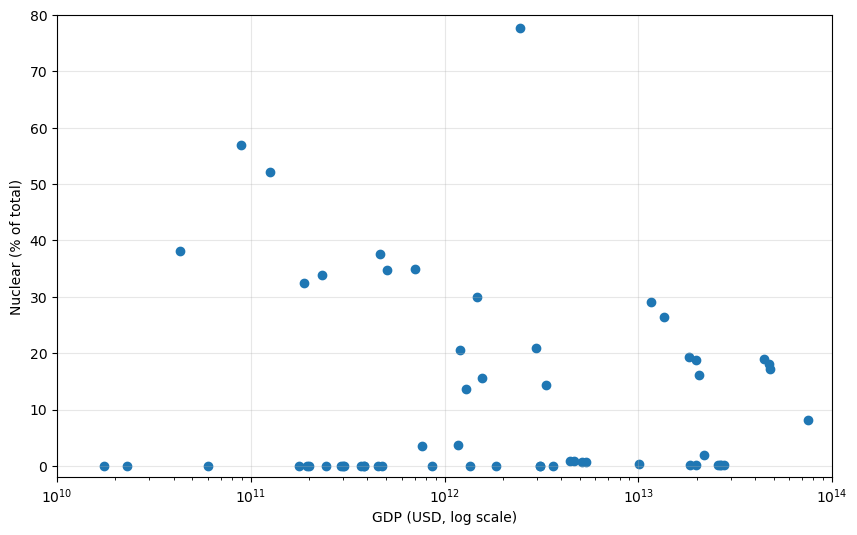

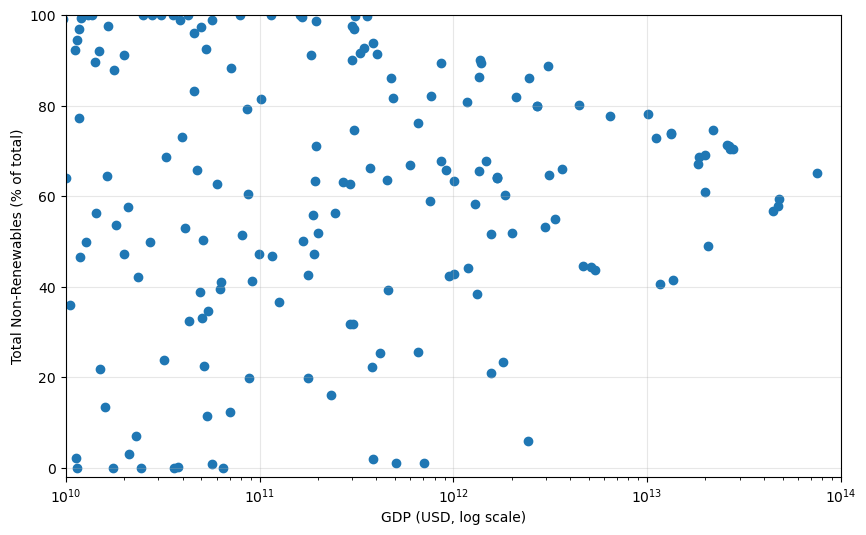

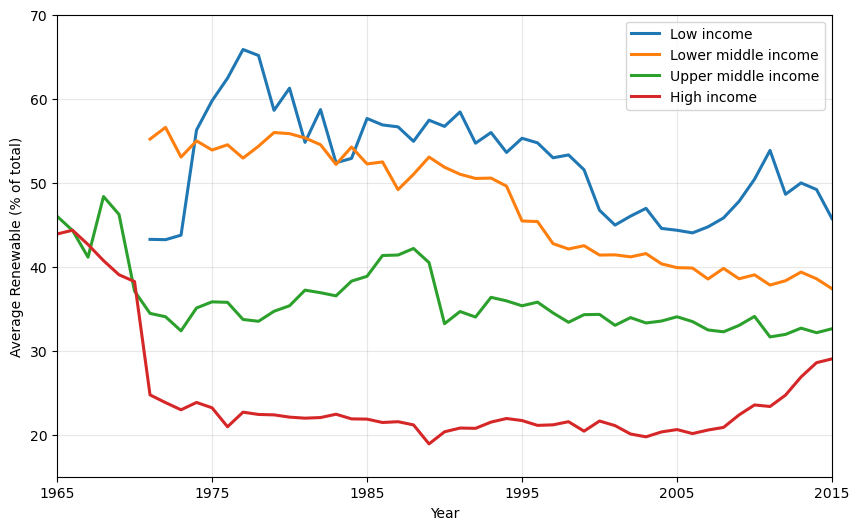

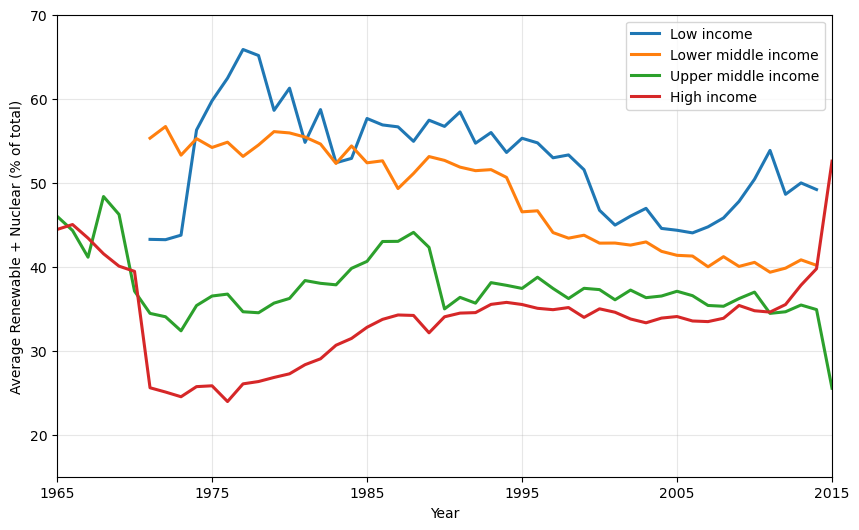

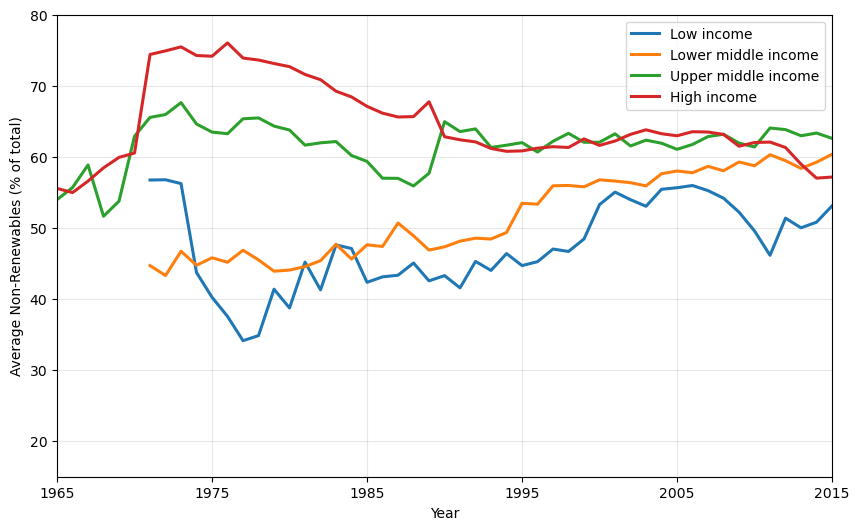

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set Up dataframes for all data sets
filename1 = "API_SP.COMBINED.TOTL_DS2_en_csv_v2.csv"
filename2 = "DP_Live_energy_Renewable.csv"
filename3 = "DP_Live_energy_PrimaryEnergySupply.csv"
filename4 = "Metadata_Country_API_SP.COMBINED.TOT_DS2_en_csv_v2.csv"

energy_percent_df = pd.read_csv(filename1)
energy_percent_df = energy_percent_df.set_index("Country Name")

renewable_energy_indicator_df = pd.read_csv(filename2, skiprows=4)
renewable_energy_indicator_df = renewable_energy_indicator_df.set_index("LOCATION")

energy_supply_df = pd.read_csv(filename3, skiprows=4)
energy_supply_df = energy_supply_df.set_index("LOCATION")

metadata_df = pd.read_csv(filename4)
metadata_df = metadata_df.set_index("TableName")

### Trends over time for renewable energy in certain regions 

# Create regions and find data
regions = ['East Asia & Pacific', 'Europe & Central Asia', 'North America']
filt = (renewable_energy_indicator_df["TIME"] >= 2000)
filtered_df = renewable_energy_indicator_df[filt]

# Plot regions for year vs KTOE
fig, ax = plt.subplots(figsize=(10,6))
colours = ["blue", "darkorange", "green"]
n = 0

for region in regions:
    data = filtered_df.loc[region]
    ax.plot(data['TIME'], data['Value'], label=region, linewidth=2.2, color=colours[n])
    n = n + 1

# Plot settings for Renewable Energy Production (2000-2018)
#ax.set_title('Renewable Energy Production (2000-2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Renewable Energy Generation (KTOE)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.set_xlim(2000,2018)
ax.set_ylim(100000, 500000)

# Mention in report that dates were chose due to missing data and this is also the only place showing an interesting relationship.






### Trends over time for the percentage contribution of renewable energy to the total over similar time periods. 

# Create total renewable energy including hydroelectic
energy_percent_df["Total renewable (% of total)"] = energy_percent_df["Hydroelectric (% of total)"] + energy_percent_df["Renewable excluding hydroelectric (% of total)"]

# Filter Data
regions = ['East Asia & Pacific', 'Europe & Central Asia', 'North America']
filt = (energy_percent_df["Year"] >= 2000)
filtered_df = energy_percent_df[filt]

# Plot regions for year vs percentage renewable. 
fig, ax = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

n = 0
colours = ["blue", "darkorange", "green"]

for region in regions:
    data = filtered_df.loc[region]
    ax[n].plot(data["Year"], data["Total renewable (% of total)"], label=region, linewidth=2.5, color=colours[n])
    
    # Format Plots
    ax[n].set_xlabel("Year")
    ax[n].set_ylabel("Renewable energy (%)")
    ax[n].grid(True, alpha=0.3)
    ax[n].xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax[n].set_xlim(2000,2015)
    ax[n].set_ylim(12, 28)
    n = n + 1
    
ax[0].set_title('East Asia & Pacific', fontsize=12)
ax[1].set_title('Europe & Central Asia', fontsize=12)
ax[2].set_title('North America', fontsize=12)

ax[0].set_ylabel("Renewable energy (%)")
ax[1].set_ylabel("")
ax[2].set_ylabel("")
#fig.suptitle("Regional Trends in Renewable Energy (% of Total), 2000-2015", fontsize=14, fontweight='bold')
plt.tight_layout(pad=2.0)





### Compare GDP against nuclear (% of total) for 2015

# Filter data
filt = (energy_percent_df["Year"] == 2015) & (energy_percent_df["GDP"] > 0)
filtered_df = energy_percent_df[filt]

# Plot data
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(filtered_df["GDP"], filtered_df["Nuclear (% of total)"])

# Format Graph
ax.set_xscale("log")
ax.set_xlabel("GDP (USD, log scale)")
ax.set_ylabel("Nuclear (% of total)")
#ax.set_title("GDP vs Nuclear Energy Share (2015)", fontsize=14, fontweight='bold')
ax.set_ylim(-2, 80)
ax.set_xlim(1e10, 1e14)
ax.grid(True, alpha=0.3)


### Compare GDP against total non-renewable (% of total) for 2015
energy_percent_df["Total non-renewables (% of total)"] = energy_percent_df["Coal (% of total)"] + energy_percent_df["Oil (% of total)"] + energy_percent_df["Natural Gas (% of total)"]

# Filter data
filt = (energy_percent_df["Year"] == 2015) & (energy_percent_df["GDP"] > 0)
filtered_df = energy_percent_df[filt]

# Plot data
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(filtered_df["GDP"], filtered_df["Total non-renewables (% of total)"])

# Format Graph
ax.set_xscale("log")
ax.set_xlabel("GDP (USD, log scale)")
ax.set_ylabel("Total Non-Renewables (% of total)")
#ax.set_title("GDP vs Nuclear Energy Share (2015)", fontsize=14, fontweight='bold')
ax.set_ylim(-2, 100)
ax.set_xlim(1e10, 1e14)
ax.grid(True, alpha=0.3)




### Compare Renewable Energy Share by Income Group Over Time (1965-2015) - Renewable Only
income_groups = ["Low income", "Lower middle income", "Upper middle income", "High income"]

# Calc average total renewable for all income_groups for each year.
combined_df = energy_percent_df.merge(metadata_df["IncomeGroup"], left_index=True, right_index=True, how="left")
combined_df = combined_df.dropna(subset=["Total renewable (% of total)"])
avg_df = (combined_df.groupby(["Year", "IncomeGroup"])["Total renewable (% of total)"].mean().reset_index())

# Plot this data
fig, ax = plt.subplots(figsize=(10,6))

for group in income_groups:
    filt = avg_df["IncomeGroup"] == group
    group_df = avg_df[filt]
    ax.plot(group_df["Year"], group_df["Total renewable (% of total)"], label=group, linewidth=2.2)

# Format the graph
ax.set_xlabel("Year")
ax.set_ylabel("Average Renewable (% of total)")
#ax.set_title("Renewable Energy Share by Income Group Over Time (1965-2015)", fontsize=14, fontweight='bold')
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_xlim(1965,2015)
ax.set_ylim(15,70)
ax.set_xticks(range(1965, 2021, 10))






### Compare Renewable and Nuclear Energy Share by Income Group Over Time (1965-2015) - Renewable and Nuclear
energy_percent_df["Total renewable + nuclear (% of total)"] = energy_percent_df["Hydroelectric (% of total)"] + energy_percent_df["Renewable excluding hydroelectric (% of total)"] + energy_percent_df["Nuclear (% of total)"]

# Calc average total renewable + nuclear for all income_groups for each year
combined_df = energy_percent_df.merge(metadata_df["IncomeGroup"], left_index=True, right_index=True, how="left")
combined_df = combined_df.dropna(subset=["Total renewable + nuclear (% of total)"])
avg_df = (combined_df.groupby(["Year", "IncomeGroup"])["Total renewable + nuclear (% of total)"].mean().reset_index())

# Plot this data
fig, ax = plt.subplots(figsize=(10,6))

for group in income_groups:
    filt = avg_df["IncomeGroup"] == group
    group_df = avg_df[filt]
    ax.plot(group_df["Year"], group_df["Total renewable + nuclear (% of total)"], label=group, linewidth=2.2)

# Format the graph
ax.set_xlabel("Year")
ax.set_ylabel("Average Renewable + Nuclear (% of total)")
#ax.set_title("Renewable + Nuclear Energy Share by Income Group Over Time (1965-2015)", fontsize=14, fontweight='bold')
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_xlim(1965,2015)
ax.set_ylim(15,70)
ax.set_xticks(range(1965, 2021, 10))



### Compare non-renewable Energy Share by income group over time (1965-2015) - Coal, Oil, Natural Gas

# Calc average total non-renewable for all income_groups for each year
combined_df = energy_percent_df.merge(metadata_df["IncomeGroup"], left_index=True, right_index=True, how="left")
combined_df = combined_df.dropna(subset=["Total non-renewables (% of total)"])
avg_df = (combined_df.groupby(["Year", "IncomeGroup"])["Total non-renewables (% of total)"].mean().reset_index())

# Plot this data
fig, ax = plt.subplots(figsize=(10,6))

for group in income_groups:
    filt = avg_df["IncomeGroup"] == group
    group_df = avg_df[filt]
    ax.plot(group_df["Year"], group_df["Total non-renewables (% of total)"], label=group, linewidth=2.2)

# Format the graph
ax.set_xlabel("Year")
ax.set_ylabel("Average Non-Renewables (% of total)")
#ax.set_title("Non-renewables Energy Share by Income Group Over Time (1965-2015)", fontsize=14, fontweight='bold')
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_xlim(1965,2015)
ax.set_ylim(15,80)
ax.set_xticks(range(1965, 2021, 10))
plt.show()
